In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report

import joblib

In [2]:
import os
os.listdir("../data/raw")

['freight_invoice_intelligence.csv']

In [3]:
df = pd.read_csv("../data/raw/freight_invoice_intelligence.csv")
df.head()

,Shipment_ID,Shipment_Date,Origin_City,Destination_City,Distance_KM,Transport_Mode,Vehicle_Type,Weight_KG,Volume_CBM,Shipment_Type,...,Payment_Status,Payment_Delay_Days,Cost_Difference,Cost_Difference_Percentage,Duplicate_Invoice_Flag,Invoice_Mismatch_Flag,Unusual_Cost_Flag,High_Risk_Vendor_Flag,Fraud_Risk_Score,Risk_Level
0,SHP000001,2025-09-02,Pune,Indore,783.8,Road,Mini Truck,741.5,2.52,Standard,...,Pending,7,-137.22,-1.31,0,0,0,0,10.3,Low
1,SHP000002,2024-01-27,Pune,Lucknow,237.2,Road,Truck,2098.3,4.66,Fragile,...,Overdue,44,-1725.39,-22.48,0,1,0,1,49.3,Medium
2,SHP000003,2025-01-10,Chandigarh,Bengaluru,531.7,Road,Trailer,1404.9,NaN,Standard,...,Paid,7,115.88,0.84,0,0,0,1,20.9,Low
3,SHP000004,2026-03-18,Pune,Hyderabad,1143.9,Road,Trailer,1341.7,4.63,Standard,...,Paid,13,-854.50,-3.73,0,0,0,1,21.6,Low
4,SHP000005,2025-07-24,Bengaluru,Lucknow,772.6,Road,Trailer,222.3,1.75,Fragile,...,Paid,15,59.07,0.41,0,0,0,0,13.6,Low


In [4]:
df.shape

(25000, 35)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 35 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Shipment_ID                 25000 non-null  str    
 1   Shipment_Date               25000 non-null  str    
 2   Origin_City                 25000 non-null  str    
 3   Destination_City            25000 non-null  str    
 4   Distance_KM                 25000 non-null  float64
 5   Transport_Mode              25000 non-null  str    
 6   Vehicle_Type                23755 non-null  str    
 7   Weight_KG                   25000 non-null  float64
 8   Volume_CBM                  23495 non-null  float64
 9   Shipment_Type               23538 non-null  str    
 10  Delivery_Days               25000 non-null  int64  
 11  Vendor_ID                   25000 non-null  str    
 12  Vendor_Name                 25000 non-null  str    
 13  Vendor_Rating               23560 non-null

In [6]:
df.isnull().sum()

Shipment_ID                      0
Shipment_Date                    0
Origin_City                      0
Destination_City                 0
Distance_KM                      0
Transport_Mode                   0
Vehicle_Type                  1245
Weight_KG                        0
Volume_CBM                    1505
Shipment_Type                 1462
Delivery_Days                    0
Vendor_ID                        0
Vendor_Name                      0
Vendor_Rating                 1440
Vendor_Experience_Years       1469
Base_Freight_Cost                0
Fuel_Cost                        0
Toll_Cost                        0
Handling_Cost                 1315
Other_Cost                       0
Total_Freight_Cost               0
Invoice_ID                       0
Invoice_Date                     0
Invoice_Amount                   0
Expected_Invoice_Amount          0
Payment_Status                   0
Payment_Delay_Days               0
Cost_Difference                  0
Cost_Difference_Perc

In [7]:
## Fill numerical and categorical values with fillna 

num_missing_cols = ["Volume_CBM", "Vendor_Rating", "Vendor_Experience_Years", "Handling_Cost"]

for col in num_missing_cols:
    df[col] = df[col].fillna(df[col].median())

## For categorical values
cat_missing_cols = ["Vehicle_Type", "Shipment_Type"]

for col in cat_missing_cols:
    df[col] = df[col].fillna(df[col].mode()[0])    

In [8]:
## Conversion of date 

df["Shipment_Date"] = pd.to_datetime(df["Shipment_Date"])
df["Invoice_Date"] = pd.to_datetime(df["Invoice_Date"])

In [9]:
df.isnull().sum()

Shipment_ID                   0
Shipment_Date                 0
Origin_City                   0
Destination_City              0
Distance_KM                   0
Transport_Mode                0
Vehicle_Type                  0
Weight_KG                     0
Volume_CBM                    0
Shipment_Type                 0
Delivery_Days                 0
Vendor_ID                     0
Vendor_Name                   0
Vendor_Rating                 0
Vendor_Experience_Years       0
Base_Freight_Cost             0
Fuel_Cost                     0
Toll_Cost                     0
Handling_Cost                 0
Other_Cost                    0
Total_Freight_Cost            0
Invoice_ID                    0
Invoice_Date                  0
Invoice_Amount                0
Expected_Invoice_Amount       0
Payment_Status                0
Payment_Delay_Days            0
Cost_Difference               0
Cost_Difference_Percentage    0
Duplicate_Invoice_Flag        0
Invoice_Mismatch_Flag         0
Unusual_

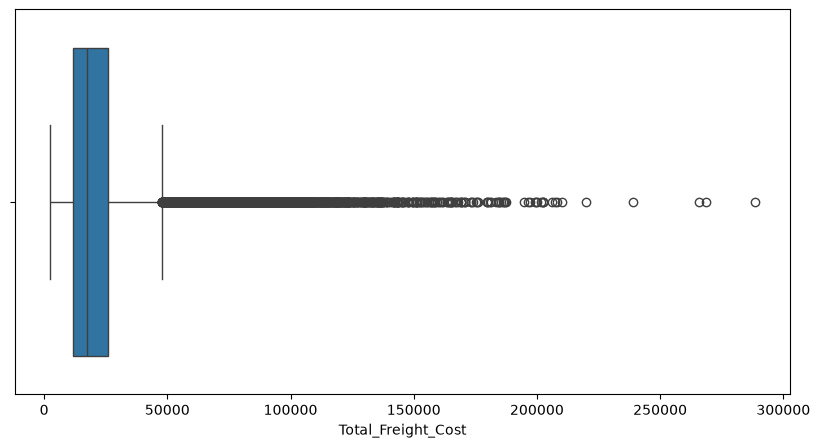

In [10]:
plt.figure(figsize=(10, 5))
sns.boxplot(x=df["Total_Freight_Cost"])
plt.show()

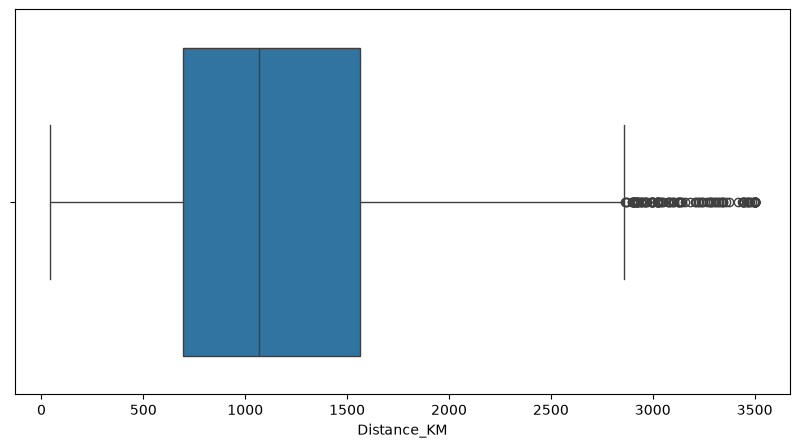

In [11]:
plt.figure(figsize=(10, 5))
sns.boxplot(x=df["Distance_KM"])
plt.show()

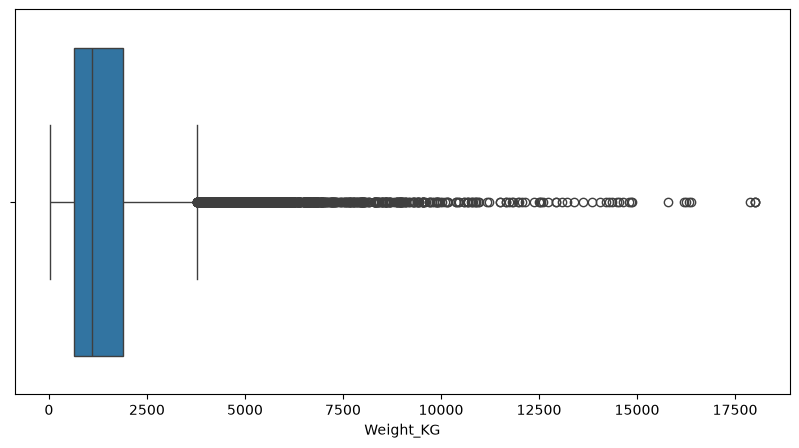

In [12]:
plt.figure(figsize=(10, 5))
sns.boxplot(x=df["Weight_KG"])
plt.show()

In [13]:
cat_cols = df.select_dtypes(include="str").columns

num_cols = df.select_dtypes(include = "number").columns

print("numerical Columns",num_cols)
print("categorcial_columns", cat_cols)

numerical Columns Index(['Distance_KM', 'Weight_KG', 'Volume_CBM', 'Delivery_Days',
       'Vendor_Rating', 'Vendor_Experience_Years', 'Base_Freight_Cost',
       'Fuel_Cost', 'Toll_Cost', 'Handling_Cost', 'Other_Cost',
       'Total_Freight_Cost', 'Invoice_Amount', 'Expected_Invoice_Amount',
       'Payment_Delay_Days', 'Cost_Difference', 'Cost_Difference_Percentage',
       'Duplicate_Invoice_Flag', 'Invoice_Mismatch_Flag', 'Unusual_Cost_Flag',
       'High_Risk_Vendor_Flag', 'Fraud_Risk_Score'],
      dtype='str')
categorcial_columns Index(['Shipment_ID', 'Origin_City', 'Destination_City', 'Transport_Mode',
       'Vehicle_Type', 'Shipment_Type', 'Vendor_ID', 'Vendor_Name',
       'Invoice_ID', 'Payment_Status', 'Risk_Level'],
      dtype='str')


In [14]:
## Save the cleaned data for sql
df.to_csv("../data/processed/freight_invoice_cleaned.csv", index=False)

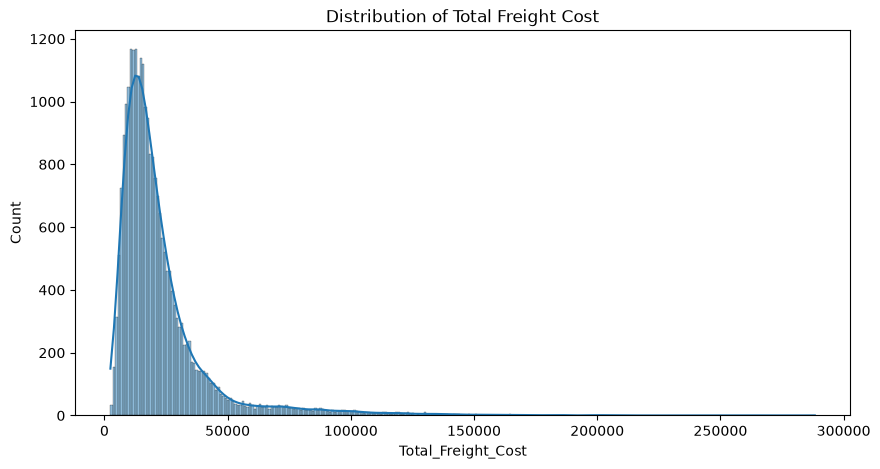

In [15]:
plt.figure(figsize=(10, 5))
sns.histplot(df["Total_Freight_Cost"], kde=True)
plt.title("Distribution of Total Freight Cost")

plt.show()

In [16]:
df["Calculated_Total"] = (
    df["Base_Freight_Cost"]
    + df["Fuel_Cost"]
    + df["Toll_Cost"]
    + df["Handling_Cost"]
    + df["Other_Cost"]
)

df[["Total_Freight_Cost", "Calculated_Total"]].head()

,Total_Freight_Cost,Calculated_Total
0,10243.03,10141.26
1,7865.60,7892.06
2,13821.67,13686.70
3,22024.09,20364.59
4,14798.98,14862.26


In [17]:
(df["Total_Freight_Cost"] - df["Calculated_Total"]).describe()

count     25000.000000
mean        906.949441
std        3600.460261
min      -26499.430000
25%        -193.465000
50%         408.780000
75%        1148.740000
max      117228.260000
dtype: float64

In [18]:
## Seperate features and target

features = ["Origin_City", "Destination_City", "Distance_KM", "Transport_Mode", "Vehicle_Type", "Weight_KG", 
            "Volume_CBM", "Shipment_Type", "Delivery_Days", "Vendor_Rating", "Vendor_Experience_Years"]

x = df[features]
y = df["Total_Freight_Cost"]

In [19]:
## Train test split 

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [20]:
x_train.shape

(20000, 11)

In [21]:
## Define numerical and categorical features

numerical_features = ["Distance_KM", "Weight_KG", "Volume_CBM", "Delivery_Days", "Vendor_Rating", "Vendor_Experience_Years"]

categorical_features = [ "Origin_City", "Destination_City", "Transport_Mode", "Vehicle_Type", "Shipment_Type"]

In [22]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [23]:
## Baseline linear regression model

linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

## Train the model
linear_model.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['Origin_City','Destination_City','Distance_KM',...,'Delivery_Days', 'Vendor_Rating','Vendor_Experience_Years']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automaticall

In [24]:
## prediction of linearregression model

y_pred = linear_model.predict(x_test)

In [25]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = mse ** 0.5

r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 4863.034655857451
MSE: 68807649.864774
RMSE: 8295.0376650606
R² Score: 0.8462077505010587


In [26]:
## preprocessing of xgboost pipeline 

xgb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", XGBRegressor(
            random_state=42
        ))
    ]
)

In [27]:
## Train the model
xgb_model.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['Origin_City','Destination_City','Distance_KM',...,'Delivery_Days', 'Vendor_Rating','Vendor_Experience_Years']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automaticall

In [28]:
## predict the model
xgb_pred = xgb_model.predict(x_test)

In [29]:
## Evaluation fo xgboost model

xgb_mae = mean_absolute_error(y_test, xgb_pred)

xgb_mse = mean_squared_error(y_test, xgb_pred)

xgb_rmse = xgb_mse ** 0.5

xgb_r2 = r2_score(y_test, xgb_pred)

print("XGBoost MAE:", xgb_mae)
print("XGBoost MSE:", xgb_mse)
print("XGBoost RMSE:", xgb_rmse)
print("XGBoost R² Score:", xgb_r2)

XGBoost MAE: 2557.015473138672
XGBoost MSE: 24562698.91276481
XGBoost RMSE: 4956.076968002496
XGBoost R² Score: 0.9450998148173462


In [30]:
param_grid = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__max_depth": [3, 5, 7, 10],
    "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "model__subsample": [0.7, 0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 0.9, 1.0]
}

In [31]:
random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_grid,
    n_iter=20,
    cv=3,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    random_state=42
)
random_search.fit(x_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__colsample_bytree': [0.7, 0.8, ...], 'model__learning_rate': [0.01, 0.05, ...], 'model__max_depth': [3, 5, ...], 'model__n_estimators': [100, 200, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` dir

In [32]:
random_search.best_params_

{'model__subsample': 0.7,
 'model__n_estimators': 500,
 'model__max_depth': 3,
 'model__learning_rate': 0.05,
 'model__colsample_bytree': 0.7}

In [33]:
random_search.best_score_

np.float64(-2448.2276595866047)

In [34]:
## Tuned xgboost model

final_freight_model = random_search.best_estimator_

final_xgb_pred = final_freight_model.predict(x_test)

In [35]:
tuned_mae = mean_absolute_error(y_test,final_xgb_pred)

tuned_mse = mean_squared_error(y_test, final_xgb_pred)

tuned_rmse = tuned_mse ** 0.5

tuned_r2 = r2_score(y_test, final_xgb_pred)

print("Tuned XGboost MAE:", tuned_mae)
print("Tuned XGboost RMSE:", tuned_rmse)
print("Tuned XGboost R²:", tuned_r2)

Tuned XGboost MAE: 2440.564581222656
Tuned XGboost RMSE: 4674.257443482528
Tuned XGboost R²: 0.9511659232713131


## Now  make model 2: Invoice Risk Prediction

In [36]:
y_risk = df["Risk_Level"]

In [37]:
df.groupby("Risk_Level")["Fraud_Risk_Score"].describe()

,count,mean,std,min,25%,50%,75%,max
Risk_Level,,,,,,,,
High,540.0,65.250185,9.727048,55.0,57.4,62.0,71.125,97.9
Low,20417.0,8.043753,6.718075,0.0,2.5,6.7,12.300,25.0
Medium,4043.0,38.265348,7.748321,25.0,32.3,38.4,43.800,55.0


In [38]:
## Make the relevent features and target columns for invoice risk prediciton 

risk_features = ["Distance_KM", "Transport_Mode", "Vehicle_Type", "Weight_KG", "Volume_CBM", "Shipment_Type",
    "Delivery_Days", "Vendor_Rating", "Vendor_Experience_Years", "Invoice_Amount", "Expected_Invoice_Amount",
    "Payment_Status", "Payment_Delay_Days"]

x_risk = df[risk_features]
y_risk = df["Risk_Level"]

In [39]:
## Train test split for invoice risk prediction 

x_risk_train, x_risk_test, y_risk_train, y_risk_test = train_test_split(x_risk, y_risk, test_size=0.2, random_state=42, stratify=y_risk)

In [40]:
x_risk_train.shape

(20000, 13)

In [41]:
## Indentify the numerical and categorical features 

risk_num_features = ["Distance_KM", "Weight_KG", "Volume_CBM", "Delivery_Days", "Vendor_Rating", "Vendor_Experience_Years",
    "Invoice_Amount", "Expected_Invoice_Amount", "Payment_Delay_Days"]

risk_cat_features = ["Transport_Mode", "Vehicle_Type", "Shipment_Type", "Payment_Status"]

In [42]:
## Create Preprocessing Pipeline

risk_preprocessor = ColumnTransformer(
    transformers = [
        ("num", StandardScaler(), risk_num_features),
        ("cat", OneHotEncoder(handle_unknown = "ignore"), risk_cat_features)
    ]
)


In [43]:
## Model Pipeline 
## I use class_weight = "balanced" because to give more importance to minority classes.

logistic_model = Pipeline(
    steps=[
        ("preprocess", risk_preprocessor),
        ("model", LogisticRegression(max_iter=1000, class_weight = "balanced"))
    ]
)

## Train the model
logistic_model.fit(x_risk_train, y_risk_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](3,)","['High','Low','Medium']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](13,)","['Distance_KM','Transport_Mode','Vehicle_Type',..., 'Expected_Invoice_Amount','Payment_Status','Payment_Delay_Days']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default 

In [44]:
y_risk_pred = logistic_model.predict(x_risk_test)

In [45]:
## Now evaluation of matrics 

accuracy_score(y_risk_test, y_risk_pred)

0.7856

In [46]:
from sklearn.metrics import classification_report
print(classification_report(y_risk_test, y_risk_pred))

              precision    recall  f1-score   support

        High       0.11      0.51      0.19       108
         Low       0.93      0.88      0.90      4083
      Medium       0.43      0.35      0.38       809

    accuracy                           0.79      5000
   macro avg       0.49      0.58      0.49      5000
weighted avg       0.83      0.79      0.80      5000



In [47]:
cm = confusion_matrix(y_risk_test, y_risk_pred, labels=["Low", "Medium", "High"])
cm

array([[3593,  332,  158],
       [ 262,  280,  267],
       [  18,   35,   55]])

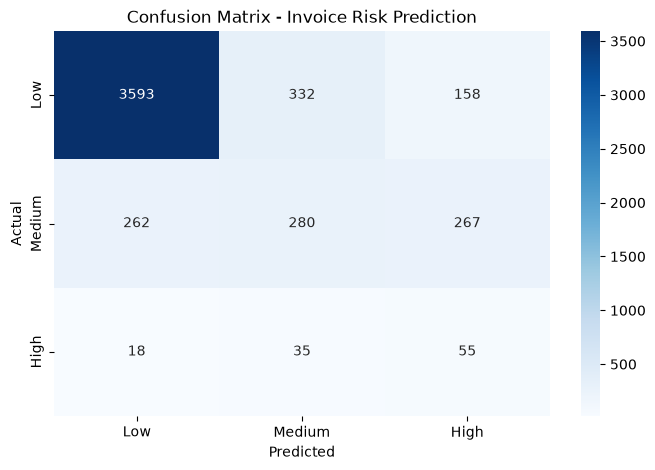

In [48]:
plt.figure(figsize=(8, 5))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Low", "Medium", "High"], yticklabels=["Low", "Medium", "High"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Invoice Risk Prediction")

plt.show()

#### Use now  XGboost classifier 

In [49]:

#  Use preprocessing  or encoding to change the target into numerical columns 

label_encoder = LabelEncoder()
y_risk_encoded = label_encoder.fit_transform(y_risk)
y_risk_encoded[:5]

array([1, 2, 1, 1, 1])

In [50]:
## Now Train Test split 

x_risk_train, x_risk_test, y_risk_train_encoded, y_risk_test_encoded = train_test_split(x_risk, y_risk_encoded, 
                                                                                        test_size=0.2, random_state=42, stratify=y_risk_encoded)

In [51]:
## use preprocessing and train the model

xgboost_classifier = Pipeline(
    steps = [
        ("preprocessing", risk_preprocessor),
        ("Model", XGBClassifier(ranodm_state = 42))
    ])

xgboost_classifier.fit(x_risk_train, y_risk_train_encoded)

C:\Users\DELL\AppData\Roaming\Python\Python314\site-packages\xgboost\training.py:200: UserWarning: [13:08:35] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:794: 
Parameters: { "ranodm_state" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('Model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](3,)","[0,1,2]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](13,)","['Distance_KM','Transport_Mode','Vehicle_Type',..., 'Expected_Invoice_Amount','Payment_Status','Payment_Delay_Days']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``)

In [52]:
## Make prediction 
y_risk_pred_xgb = xgboost_classifier.predict(x_risk_test)

In [53]:
## Evaluation of xgboost model

accuracy = accuracy_score(y_risk_test_encoded, y_risk_pred_xgb)
accuracy

0.893

In [54]:
## See the classification report 

print(classification_report(y_risk_test_encoded, y_risk_pred_xgb, target_names = label_encoder.classes_))

              precision    recall  f1-score   support

        High       0.42      0.05      0.08       108
         Low       0.91      0.99      0.95      4083
      Medium       0.79      0.53      0.63       809

    accuracy                           0.89      5000
   macro avg       0.71      0.52      0.55      5000
weighted avg       0.88      0.89      0.88      5000



### XGBoost achieve 89.3% accuracy but with only 5% of High-risk invoice or recall. So, we choose logistic regression  as final model. Although i  use here, class_weight = "balanced" because it acieve 78.6% accuracy but also with 51% high risk recall.

In [55]:
## Save both the model Freight Cost Prediction model    and invoice risk prediction model

joblib.dump(final_freight_model, "../model/freight_cost_model.pkl")

joblib.dump(logistic_model, "../model/invoice_risk_model.pkl")

['../model/invoice_risk_model.pkl']